<a href="https://colab.research.google.com/github/Mubiala/TP-LOGIQUE-FLOUE-en-IA/blob/main/TP_de_Logique_Floue.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SYSTÈME EXPERT FLOU POUR LE DIAGNOSTIC DU PALUDISME
Modèles de Mamdani et Sugeno - Implémentation manuelle


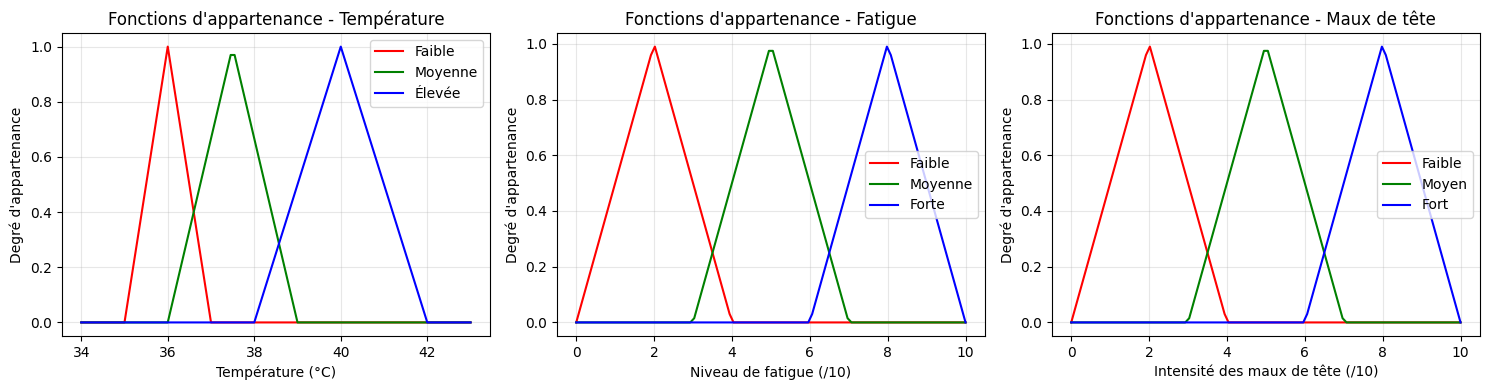


PATIENT : Température = 39°C, Fatigue = 7/10, Maux = 8/10

----------------------------------------
MODÈLE DE MAMDANI
----------------------------------------

--- FUZZIFICATION ---
Température 39°C : {'Faible': 0.0, 'Moyenne': 0.0, 'Élevée': 0.5}
Fatigue 7/10 : {'Faible': 0.0, 'Moyenne': 0.0, 'Forte': 0.5}
Maux de tête 8/10 : {'Faible': 0.0, 'Moyen': 0.0, 'Fort': 1.0}

--- ACTIVATION DES RÈGLES ---
Règle  1 : Élevée & Forte & Fort -> Élevé (activation = 0.500)

--- AGRÉGATION ---
Risque Faible : 0.000
Risque Moyen  : 0.000
Risque Élevé  : 0.500

--- DÉFUZZIFICATION ---
Risque = 80.00 %

----------------------------------------
MODÈLE DE SUGENO
----------------------------------------

--- FUZZIFICATION (Sugeno) ---
Température 39°C : {'Faible': 0.0, 'Moyenne': 0.0, 'Élevée': 0.5}
Fatigue 7/10 : {'Faible': 0.0, 'Moyenne': 0.0, 'Forte': 0.5}
Maux de tête 8/10 : {'Faible': 0.0, 'Moyen': 0.0, 'Fort': 1.0}

--- ACTIVATION DES RÈGLES (Sugeno) ---
Règle  1 : Élevée & Forte & Fort -> Risque 

In [ ]:
# -*- coding: utf-8 -*-
"""
SYSTÈME EXPERT FLOU POUR LE DIAGNOSTIC DU PALUDISME
Modèles de Mamdani et Sugeno - Implémentation manuelle
Auteurs : MUBIALA KIESE SAMUEL, LUVETO DIALUNGANA SALOMON, WABA MPWO EXAUCE
"""

import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# 1. FONCTIONS D'APPARTENANCE (TRIANGULAIRES)
# ============================================================================

def fonction_triangulaire(x, a, b, c):
    """
    Fonction d'appartenance triangulaire.

    Paramètres:
        x : valeur à évaluer
        a : début du triangle
        b : sommet du triangle
        c : fin du triangle

    Retourne:
        degré d'appartenance entre 0 et 1
    """
    if x <= a or x >= c:
        return 0.0
    elif a < x <= b:
        return (x - a) / (b - a)
    else:  # b < x < c
        return (c - x) / (c - b)


def fuzzification_temp(temperature):
    """
    Fuzzification de la température corporelle.

    Ensembles flous:
        - Faible  : (35, 36, 37)
        - Moyenne : (36, 37.5, 39)
        - Élevée  : (38, 40, 42)
    """
    faible = fonction_triangulaire(temperature, 35, 36, 37)
    moyenne = fonction_triangulaire(temperature, 36, 37.5, 39)
    elevee = fonction_triangulaire(temperature, 38, 40, 42)
    return {'Faible': faible, 'Moyenne': moyenne, 'Élevée': elevee}


def fuzzification_fatigue(fatigue):
    """
    Fuzzification du niveau de fatigue.

    Ensembles flous:
        - Faible : (0, 2, 4)
        - Moyenne: (3, 5, 7)
        - Forte  : (6, 8, 10)
    """
    faible = fonction_triangulaire(fatigue, 0, 2, 4)
    moyenne = fonction_triangulaire(fatigue, 3, 5, 7)
    forte = fonction_triangulaire(fatigue, 6, 8, 10)
    return {'Faible': faible, 'Moyenne': moyenne, 'Forte': forte}


def fuzzification_maux(maux):
    """
    Fuzzification de l'intensité des maux de tête.

    Ensembles flous:
        - Faible : (0, 2, 4)
        - Moyen  : (3, 5, 7)
        - Fort   : (6, 8, 10)
    """
    faible = fonction_triangulaire(maux, 0, 2, 4)
    moyen = fonction_triangulaire(maux, 3, 5, 7)
    fort = fonction_triangulaire(maux, 6, 8, 10)
    return {'Faible': faible, 'Moyen': moyen, 'Fort': fort}


# ============================================================================
# 2. BASE DE RÈGLES FLOUES
# ============================================================================

# Règles pour Mamdani (sortie : ensemble flou)
regles_mamdani = [
    # R1 : Élevé
    ('Élevée', 'Forte', 'Fort', 'Élevé'),
    # R2 : Élevé
    ('Élevée', 'Forte', 'Moyen', 'Élevé'),
    # R3 : Élevé
    ('Élevée', 'Moyenne', 'Fort', 'Élevé'),
    # R4 : Moyen
    ('Moyenne', 'Moyenne', 'Moyen', 'Moyen'),
    # R5 : Moyen
    ('Moyenne', 'Forte', 'Moyen', 'Moyen'),
    # R6 : Moyen
    ('Moyenne', 'Moyenne', 'Fort', 'Moyen'),
    # R7 : Faible
    ('Faible', 'Faible', 'Faible', 'Faible'),
    # R8 : Faible
    ('Faible', 'Moyenne', 'Faible', 'Faible'),
    # R9 : Faible
    ('Moyenne', 'Faible', 'Faible', 'Faible'),
    # R10 : Moyen
    ('Élevée', 'Forte', 'Faible', 'Moyen'),
    # R11 : Moyen
    ('Faible', 'Forte', 'Fort', 'Moyen'),
    # R12 : Élevé
    ('Moyenne', 'Forte', 'Fort', 'Élevé'),
]

# Règles pour Sugeno (sortie : valeur numérique)
regles_sugeno = [
    ('Élevée', 'Forte', 'Fort', 85),
    ('Élevée', 'Forte', 'Moyen', 85),
    ('Élevée', 'Moyenne', 'Fort', 85),
    ('Moyenne', 'Moyenne', 'Moyen', 50),
    ('Moyenne', 'Forte', 'Moyen', 50),
    ('Moyenne', 'Moyenne', 'Fort', 50),
    ('Faible', 'Faible', 'Faible', 25),
    ('Faible', 'Moyenne', 'Faible', 25),
    ('Moyenne', 'Faible', 'Faible', 25),
    ('Élevée', 'Forte', 'Faible', 50),
    ('Faible', 'Forte', 'Fort', 50),
    ('Moyenne', 'Forte', 'Fort', 85),
]

# Valeurs représentatives pour la défuzzification (centre des triangles)
valeurs_risque = {
    'Faible': 20,    # centre du triangle (0, 20, 40)
    'Moyen': 50,     # centre du triangle (30, 50, 70)
    'Élevé': 80      # centre du triangle (60, 80, 100)
}


# ============================================================================
# 3. MODÈLE DE MAMDANI
# ============================================================================

def inference_mamdani(temp, fatigue, maux):
    """
    Inférence floue selon le modèle de Mamdani.

    Étapes:
        1. Fuzzification des entrées
        2. Activation des règles (opérateur MIN)
        3. Agrégation (opérateur MAX)
        4. Défuzzification (centre de gravité)
    """

    # Étape 1 : Fuzzification
    temp_fuzz = fuzzification_temp(temp)
    fatigue_fuzz = fuzzification_fatigue(fatigue)
    maux_fuzz = fuzzification_maux(maux)

    print("\n--- FUZZIFICATION ---")
    print(f"Température {temp}°C : {temp_fuzz}")
    print(f"Fatigue {fatigue}/10 : {fatigue_fuzz}")
    print(f"Maux de tête {maux}/10 : {maux_fuzz}")

    # Étape 2 & 3 : Activation des règles et agrégation
    activation_par_risque = {'Faible': 0.0, 'Moyen': 0.0, 'Élevé': 0.0}

    print("\n--- ACTIVATION DES RÈGLES ---")
    for i, (t_cond, f_cond, m_cond, risque) in enumerate(regles_mamdani, 1):
        # Récupérer les degrés d'appartenance
        deg_t = temp_fuzz[t_cond]
        deg_f = fatigue_fuzz[f_cond]
        deg_m = maux_fuzz[m_cond]

        # Activation = MIN des conditions
        activation = min(deg_t, deg_f, deg_m)

        if activation > 0:
            print(f"Règle {i:2d} : {t_cond} & {f_cond} & {m_cond} -> {risque} (activation = {activation:.3f})")
            # Agrégation : MAX pour chaque niveau de risque
            activation_par_risque[risque] = max(activation_par_risque[risque], activation)

    print(f"\n--- AGRÉGATION ---")
    print(f"Risque Faible : {activation_par_risque['Faible']:.3f}")
    print(f"Risque Moyen  : {activation_par_risque['Moyen']:.3f}")
    print(f"Risque Élevé  : {activation_par_risque['Élevé']:.3f}")

    # Étape 4 : Défuzzification par centre de gravité
    numerateur = 0.0
    denominateur = 0.0

    for risque, activation in activation_par_risque.items():
        numerateur += valeurs_risque[risque] * activation
        denominateur += activation

    if denominateur == 0:
        risque_final = 0
    else:
        risque_final = numerateur / denominateur

    print(f"\n--- DÉFUZZIFICATION ---")
    print(f"Risque = {risque_final:.2f} %")

    return risque_final, activation_par_risque


# ============================================================================
# 4. MODÈLE DE SUGENO
# ============================================================================

def inference_sugeno(temp, fatigue, maux):
    """
    Inférence floue selon le modèle de Sugeno.

    Étapes:
        1. Fuzzification des entrées
        2. Calcul des poids des règles (MIN)
        3. Moyenne pondérée des sorties numériques
    """

    # Étape 1 : Fuzzification
    temp_fuzz = fuzzification_temp(temp)
    fatigue_fuzz = fuzzification_fatigue(fatigue)
    maux_fuzz = fuzzification_maux(maux)

    print("\n--- FUZZIFICATION (Sugeno) ---")
    print(f"Température {temp}°C : {temp_fuzz}")
    print(f"Fatigue {fatigue}/10 : {fatigue_fuzz}")
    print(f"Maux de tête {maux}/10 : {maux_fuzz}")

    # Étape 2 & 3 : Calcul des poids et moyenne pondérée
    numerateur = 0.0
    denominateur = 0.0

    print("\n--- ACTIVATION DES RÈGLES (Sugeno) ---")
    for i, (t_cond, f_cond, m_cond, valeur) in enumerate(regles_sugeno, 1):
        deg_t = temp_fuzz[t_cond]
        deg_f = fatigue_fuzz[f_cond]
        deg_m = maux_fuzz[m_cond]

        poids = min(deg_t, deg_f, deg_m)

        if poids > 0:
            print(f"Règle {i:2d} : {t_cond} & {f_cond} & {m_cond} -> Risque = {valeur} (poids = {poids:.3f})")
            numerateur += poids * valeur
            denominateur += poids

    if denominateur == 0:
        risque_final = 0
    else:
        risque_final = numerateur / denominateur

    print(f"\n--- SORTIE FINALE ---")
    print(f"Risque = {risque_final:.2f} %")

    return risque_final


# ============================================================================
# 5. VISUALISATION DES FONCTIONS D'APPARTENANCE
# ============================================================================

def tracer_fonctions_appartenance():
    """Trace les fonctions d'appartenance des trois variables."""

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Température
    x_temp = np.linspace(34, 43, 100)
    axes[0].plot(x_temp, [fonction_triangulaire(x, 35, 36, 37) for x in x_temp], 'r-', label='Faible')
    axes[0].plot(x_temp, [fonction_triangulaire(x, 36, 37.5, 39) for x in x_temp], 'g-', label='Moyenne')
    axes[0].plot(x_temp, [fonction_triangulaire(x, 38, 40, 42) for x in x_temp], 'b-', label='Élevée')
    axes[0].set_xlabel('Température (°C)')
    axes[0].set_ylabel('Degré d\'appartenance')
    axes[0].set_title('Fonctions d\'appartenance - Température')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Fatigue
    x_fatigue = np.linspace(0, 10, 100)
    axes[1].plot(x_fatigue, [fonction_triangulaire(x, 0, 2, 4) for x in x_fatigue], 'r-', label='Faible')
    axes[1].plot(x_fatigue, [fonction_triangulaire(x, 3, 5, 7) for x in x_fatigue], 'g-', label='Moyenne')
    axes[1].plot(x_fatigue, [fonction_triangulaire(x, 6, 8, 10) for x in x_fatigue], 'b-', label='Forte')
    axes[1].set_xlabel('Niveau de fatigue (/10)')
    axes[1].set_ylabel('Degré d\'appartenance')
    axes[1].set_title('Fonctions d\'appartenance - Fatigue')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Maux de tête
    x_maux = np.linspace(0, 10, 100)
    axes[2].plot(x_maux, [fonction_triangulaire(x, 0, 2, 4) for x in x_maux], 'r-', label='Faible')
    axes[2].plot(x_maux, [fonction_triangulaire(x, 3, 5, 7) for x in x_maux], 'g-', label='Moyen')
    axes[2].plot(x_maux, [fonction_triangulaire(x, 6, 8, 10) for x in x_maux], 'b-', label='Fort')
    axes[2].set_xlabel('Intensité des maux de tête (/10)')
    axes[2].set_ylabel('Degré d\'appartenance')
    axes[2].set_title('Fonctions d\'appartenance - Maux de tête')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# ============================================================================
# 6. TESTS ET COMPARAISON
# ============================================================================

def tester_patient(temp, fatigue, maux):
    """
    Teste un patient sur les deux modèles et affiche les résultats.
    """
    print("\n" + "="*60)
    print(f"PATIENT : Température = {temp}°C, Fatigue = {fatigue}/10, Maux = {maux}/10")
    print("="*60)

    print("\n" + "-"*40)
    print("MODÈLE DE MAMDANI")
    print("-"*40)
    risque_mamdani, _ = inference_mamdani(temp, fatigue, maux)

    print("\n" + "-"*40)
    print("MODÈLE DE SUGENO")
    print("-"*40)
    risque_sugeno = inference_sugeno(temp, fatigue, maux)

    print("\n" + "-"*40)
    print("COMPARAISON")
    print("-"*40)
    print(f"Mamdani : {risque_mamdani:.2f} %")
    print(f"Sugeno  : {risque_sugeno:.2f} %")
    print(f"Écart    : {abs(risque_mamdani - risque_sugeno):.2f} %")

    # Interprétation
    def interpreter(risque):
        if risque < 40:
            return "Faible"
        elif risque < 70:
            return "Moyen"
        else:
            return "Élevé"

    print(f"\nInterprétation Mamdani : Risque {interpreter(risque_mamdani)}")
    print(f"Interprétation Sugeno  : Risque {interpreter(risque_sugeno)}")

    return risque_mamdani, risque_sugeno


# ============================================================================
# 7. EXÉCUTION PRINCIPALE
# ============================================================================

if __name__ == "__main__":
    print("="*60)
    print("SYSTÈME EXPERT FLOU POUR LE DIAGNOSTIC DU PALUDISME")
    print("Modèles de Mamdani et Sugeno - Implémentation manuelle")
    print("="*60)

    # Tracer les fonctions d'appartenance
    tracer_fonctions_appartenance()

    # Définir les patients à tester
    patients = [
        (39, 7, 8),   # Patient 1 : forte fièvre, fatigue intense, maux sévères
        (37, 5, 4),   # Patient 2 : symptômes modérés
        (36, 2, 2),   # Patient 3 : symptômes faibles
        (38, 8, 6),   # Patient 4 : fièvre modérée, forte fatigue, maux moyens
        (40, 9, 9),   # Patient 5 : symptômes très sévères
    ]

    # Stocker les résultats pour le tableau final
    results = []

    for temp, fatigue, maux in patients:
        m, s = tester_patient(temp, fatigue, maux)
        results.append((temp, fatigue, maux, m, s))

    # Afficher le tableau récapitulatif
    print("\n" + "="*60)
    print("TABLEAU RÉCAPITULATIF DES RÉSULTATS")
    print("="*60)
    print(f"{'T(°C)':<6} {'Fatigue':<8} {'Maux':<6} {'Mamdani(%)':<12} {'Sugeno(%)':<12} {'Écart':<8}")
    print("-"*60)
    for t, f, m, mam, sug in results:
        print(f"{t:<6} {f:<8} {m:<6} {mam:<12.2f} {sug:<12.2f} {abs(mam-sug):<8.2f}")